# House Price Prediction — Standardized ML Pipeline

Predict the median California house value **MedHouseVal** (regression) using a clean, leakage-free pipeline.

**Pipeline order:** Basic Analysis -> Train/Test Split -> EDA -> Feature Engineering -> Encoding -> Outlier Handling -> Scaling -> Models.

> This dataset ships with scikit-learn (`fetch_california_housing`), so there is no CSV file or Google Drive mount needed. Every data-driven step is fit on the **training set only**.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame  # features + target (MedHouseVal)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print('Shape:', df.shape)
df.info()

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## 2. Train-Test Split (done early to prevent data leakage)

In [6]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (16512, 8) | Test: (4128, 8)


## 3. EDA (training data only)

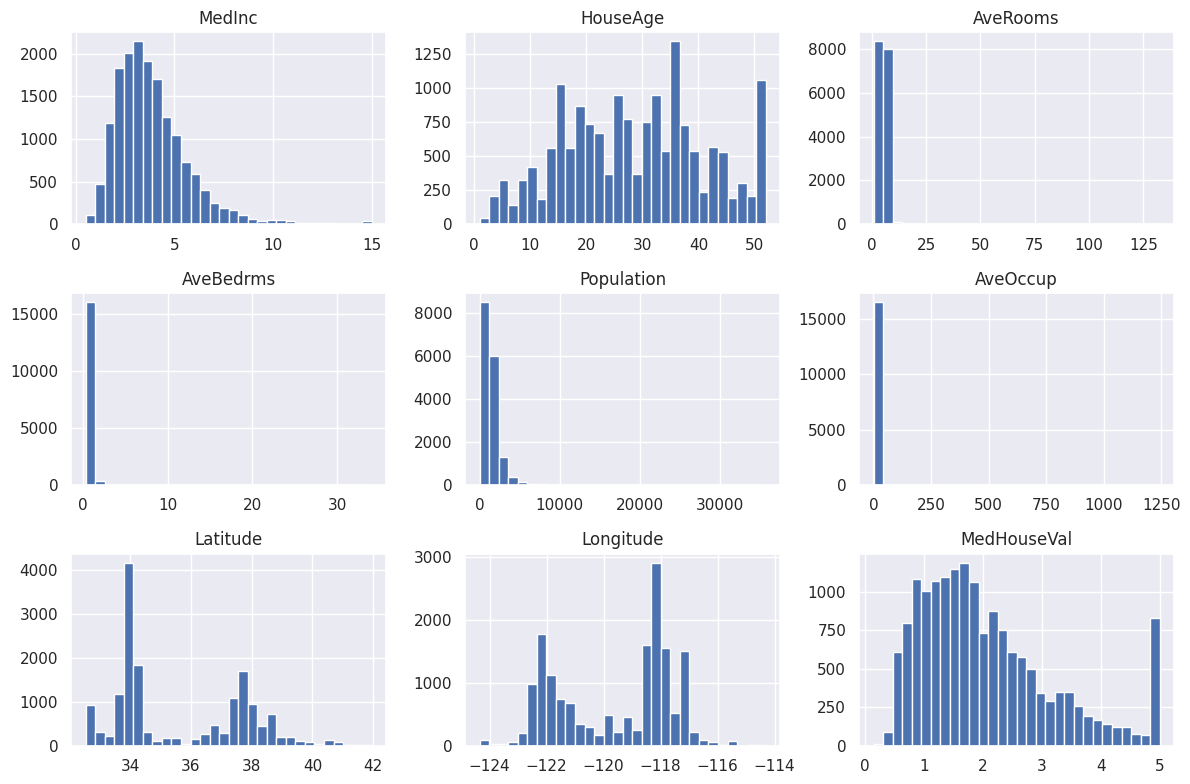

In [7]:
train_df = X_train.copy()
train_df['MedHouseVal'] = y_train

train_df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

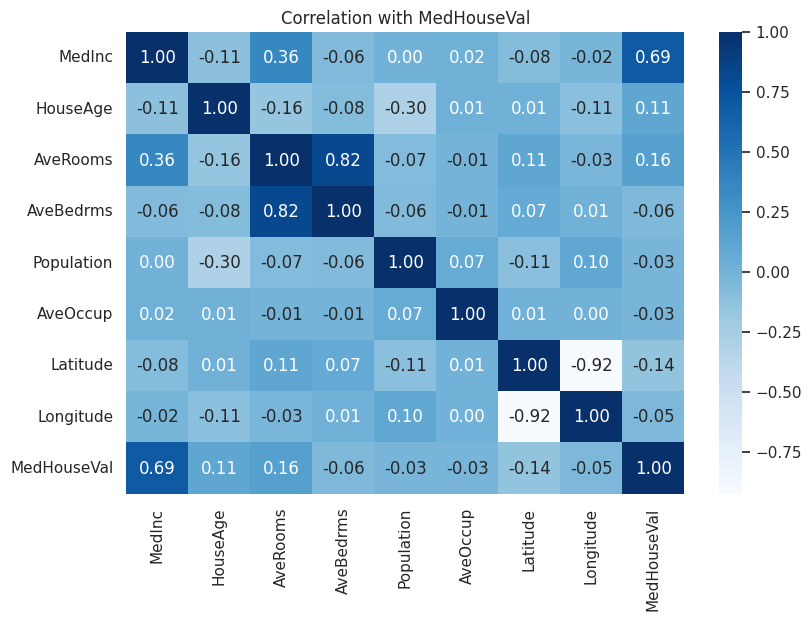

In [8]:
plt.figure(figsize=(9, 6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation with MedHouseVal')
plt.show()

## 4. Feature Engineering

- `bedroom_ratio` = average bedrooms / average rooms (a measure of how bedroom-heavy the housing is)

Applied identically to train and test.

In [9]:
def add_features(data):
    data = data.copy()
    data['bedroom_ratio'] = data['AveBedrms'] / data['AveRooms']
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,bedroom_ratio
2072,1.4817,6.0,4.443645,1.134293,1397.0,3.350120,36.77,-119.84,0.255262
10600,6.9133,8.0,5.976471,1.026471,862.0,2.535294,33.68,-117.80,0.171752
2494,1.5536,25.0,4.088785,1.000000,931.0,4.350467,36.60,-120.19,0.244571
4284,1.5284,31.0,2.740088,1.008811,597.0,2.629956,34.10,-118.32,0.368167
16541,4.0815,21.0,5.166667,1.002688,1130.0,3.037634,37.79,-121.23,0.194069


## 5. Encoding (One-Hot for nominal categoricals)

All features are numeric, so there is nothing to encode (safe no-op, kept for a consistent pipeline).

In [10]:
cat_cols = []  # no categorical features in this dataset

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,bedroom_ratio
2072,1.4817,6.0,4.443645,1.134293,1397.0,3.350120,36.77,-119.84,0.255262
10600,6.9133,8.0,5.976471,1.026471,862.0,2.535294,33.68,-117.80,0.171752
2494,1.5536,25.0,4.088785,1.000000,931.0,4.350467,36.60,-120.19,0.244571
4284,1.5284,31.0,2.740088,1.008811,597.0,2.629956,34.10,-118.32,0.368167
16541,4.0815,21.0,5.166667,1.002688,1130.0,3.037634,37.79,-121.23,0.194069


## 6. Outlier Handling — IQR vs Z-score vs Winsorization (auto-select best)

Applied to the **training set only**. This dataset has strong outliers in `AveRooms`, `AveBedrms`, `AveOccup`, and `Population`.

In [11]:
outlier_cols = ['MedInc', 'AveRooms', 'AveBedrms', 'AveOccup', 'Population']

def cv_score(Xc, yc):
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    return cross_val_score(model, Xc, yc, cv=5, scoring='r2').mean()

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

scores = {}
scores['none'] = cv_score(X_train, y_train)
scores['iqr'] = cv_score(*iqr_clean(X_train, y_train, outlier_cols))
scores['zscore'] = cv_score(*zscore_clean(X_train, y_train, outlier_cols))
scores['winsorize'] = cv_score(*winsor_clean(X_train, y_train, outlier_cols))

for k, v in scores.items():
    print(f'{k:10s} CV R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       CV R2: 0.8025
iqr        CV R2: 0.7808
zscore     CV R2: 0.7841
winsorize  CV R2: 0.7986

Best outlier method: none


In [12]:
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 16512


## 7. Feature Scaling — Standard vs MinMax vs Robust (auto-select best)

In [13]:
scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.6623
minmax     CV R2 (KNN): 0.6950
robust     CV R2 (KNN): 0.6720

Best scaler: minmax


## 8. Model Training & Comparison

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Random Forest,0.805923,0.332538,0.511299
1,Gradient Boosting,0.785953,0.366594,0.536960
2,KNN,0.691650,0.424422,0.644481
3,Linear Regression,0.613961,0.526152,0.721113


In [15]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 4))
print('Test RMSE  :', round(best_row['RMSE'], 4))

Best model : Random Forest
Test R2    : 0.8059
Test MAE   : 0.3325
Test RMSE  : 0.5113
